# Verify black-white symmetry: isomorphic LLNA rules

## Written out in detail

Let us check this in more detail. We may write the local update rule more explicitly:
\begin{equation*}
    \phi(s_i, \rho_i) = \begin{cases}
        1, \qquad \text{if } s_i = 0 \text{ and } \rho_i \in \bigcup B,\\
        1, \qquad \text{if } s_i = 1 \text{ and } \rho_i \in \bigcup S,\\
        0, \qquad \text{if } s_i = 0 \text{ and } \rho_i \not\in \bigcup B,\\
        0, \qquad \text{if } s_i = 1 \text{ and } \rho_i \not\in \bigcup S.\\
    \end{cases}
\end{equation*}
Here $B$ and $S$ are subsets of
\begin{equation*}
    R = \{R_0, R_1, \ldots, R_{r-1}\} = \left\{\left[0, \frac{1}{r}\right[, \left[\frac{1}{r}, \frac{2}{r}\right[, \ldots, \left[\frac{r-1}{r}, 1\right]\right\},
\end{equation*}
for some resolution $r \in \mathbb{N}$.

Now, if every $0$ becomes a $1$ and vice versa, we find for example
\begin{equation*}
\left(0 \mapsto 1 \text{ if } \rho \in \left[0, \frac{1}{2}\right[\right) \mapsto \left(1 \mapsto 0 \text{ if } (1-\rho) \in \left[0, \frac{1}{2}\right[\right).
\end{equation*}
More generally, this black-white switch turns the local update rule into ...
\begin{equation*}
    \phi(s_i, \rho_i) = \begin{cases}
        0, \qquad \text{if } s_i = 1 \text{ and } (1-\rho_i) \in \bigcup B,\\
        0, \qquad \text{if } s_i = 0 \text{ and } (1-\rho_i) \in \bigcup S,\\
        1, \qquad \text{if } s_i = 1 \text{ and } (1-\rho_i) \not\in \bigcup B,\\
        1, \qquad \text{if } s_i = 0 \text{ and } (1-\rho_i) \not\in \bigcup S.\\
    \end{cases}
\end{equation*}
We may re-write this by noticing that
\begin{align*}
(1-\rho) \in \bigcup B \iff \rho \in \bigcup \bar{B},
\end{align*}
where $\bar{B}$ is the mirrored density set. More specifically,
\begin{align*}
B = \{R_{k_0}, R_{k_1}, \ldots, R_{k_n}\} \iff \bar{B} = \{R_{r-1-k_0}, R_{r-1-k_1}, \ldots, R_{r-1-k_n}\}
\end{align*}
with **one clear exception**: $R_0$ is a half-open interval, whilst $R_{r-1}$ is a closed interval. **Therefore they cannot simply be mixed**.
Let us assume for a moment that neither $S$ nor $B$ contains intervals $R_0$ or $R_{r-1}$, then the above equation simplifies to
\begin{align*}
    \phi(s_i, \rho_i) &= \begin{cases}
        0, \qquad \text{if } s_i = 1 \text{ and } \rho_i \in \bigcup \bar{B},\\
        0, \qquad \text{if } s_i = 0 \text{ and } \rho_i \in \bigcup \bar{S},\\
        1, \qquad \text{if } s_i = 1 \text{ and } \rho_i \not\in \bigcup \bar{B},\\
        1, \qquad \text{if } s_i = 0 \text{ and } \rho_i \not\in \bigcup \bar{S}.\\
    \end{cases}
    &= \begin{cases}
        1, \qquad \text{if } s_i = 0 \text{ and } \rho_i \in \bigcup \bar{S}^\text{C}.\\
        1, \qquad \text{if } s_i = 1 \text{ and } \rho_i \in \bigcup \bar{B}^\text{C},\\
        0, \qquad \text{else}
    \end{cases}
\end{align*}
This implies that a black-white isomorpism is justified if the sets are mapped to resp. $B \mapsto \bar{S}^\text{C}$ and $S \mapsto \bar{B}^\text{C}$.

## Notation

We compactly write the local update rule as $R_r B_\beta S_\sigma$, where the $\beta$ and $\sigma$ subscripts are decimals. Inspired by the notation for elementary CAs, the value of these decimals is
\begin{equation*}
    \beta = \sum_{i : R_i \in B} 2^i, \qquad \sigma = \sum_{i : R_i \in S} 2^i,
\end{equation*}
such that $0 \leq \beta, \sigma \leq 2^r-1$. We write the Game of Life as $R_9 B_8 S_{12}$. There are $2^{2r}$ distinct LLNAs for a resolution $r$.

Now, for a mapping from the set of intervals $B$ to its mirror set $\bar{B}$, the $\beta$ value would be
\begin{equation*}
    \bar{\beta} = \sum_{i : R_i \in B} 2^{r-1-i}.
\end{equation*}
When mapping this to its complement set, the value becomes
\begin{equation*}
    \bar{\beta}^\text{C} = 2^{r-1} - \sum_{i : R_i \in B} 2^{r-1-i}.
\end{equation*}
As a final step, note that the mapping also implies switching from "survival" set to "born" set and vice versa: $B \mapsto \bar{S}^\text{C}$ and $S \mapsto \bar{B}^\text{C}$, so
\begin{equation*}
    \beta \mapsto \bar{\sigma}^\text{C}, \qquad \sigma \mapsto \bar{\beta}^\text{C},
\end{equation*}

We have an 'isomorphism' between LLNA rules
\begin{equation}
    R_r B_\beta S_\sigma \sim R_r B_{\bar{\sigma}^\text{C}} S_{\bar{\beta}^\text{C}}
\end{equation}
upon state inversion. However, keep in mind that ...
> This supposes that $R_0, R_{r-1} \not\in B, S$.

Why is this still not good? It does not result in identical simulations :( Not clear how to proceed ... But probably wise to
1. Check for totalistic cellular automata (regular graph)
2. ...

In [51]:
import torch as tc
import igraph as ig
import numpy as np
from matplotlib import pyplot as plt

import scipy.linalg

import sys, os
current_dir = os.getcwd()
parent_dir = os.path.abspath(os.path.join(current_dir, '..'))
sys.path.append(parent_dir)

from src.datasets import NetworksDataset
from src.automata import LLNA
from src.simulation import *
from src.analysis import jacobian, jacobian_ECA, calculate_Yt, lyapunov_spectrum

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


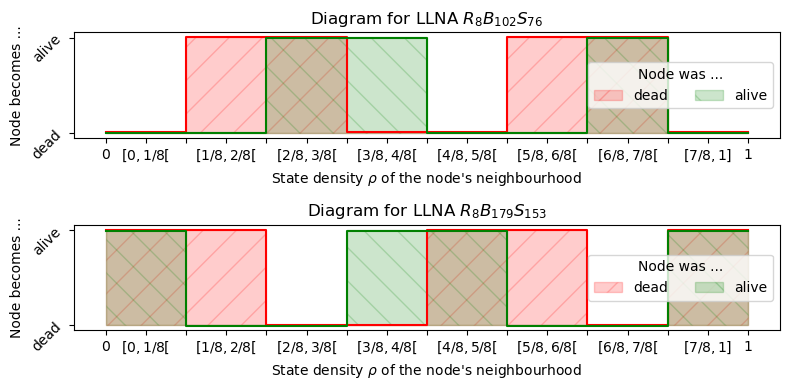

In [68]:
SAVEFIG=False

resolution = 8
born_if = [1, 2, 5, 6]
survive_if = [2, 3, 6]

# born_if_iso = resolution-1-np.array(born_if)
born_if_iso = list(set(range(resolution))-set(born_if))
# survive_if_iso = resolution-1-np.array(survive_if)
survive_if_iso = list(set(range(resolution))-set(survive_if))

# assign rules and switch survival and born set
model = LLNA(resolution, x=born_if, y=survive_if)
model_iso = LLNA(resolution, x=survive_if_iso, y=born_if_iso)

fig, axs = plt.subplots(2,1,figsize=(8, 4))
model.diagram(ax=axs[0])
model_iso.diagram(ax=axs[1])
fig.tight_layout()

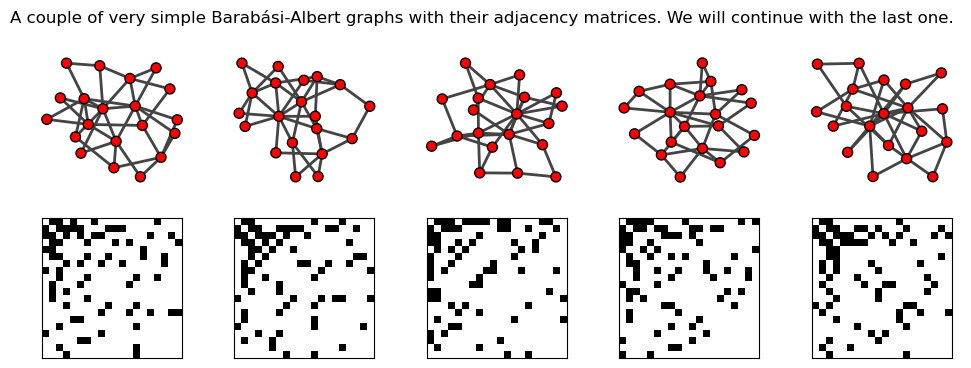

In [69]:
# some simulations to verify this results

# make a simple network

# a simple network
N = 20
min_edges = 2
Gs = [ig.Graph.Barabasi(N, min_edges) for _ in range(5)]

vertex_size=10
fig, axs = plt.subplots(2,5,figsize=(12,4))
for G, ax_top, ax_bottom in zip(Gs, axs[0], axs[1]):
    ig.plot(G, target=ax_top, vertex_size=vertex_size)
    A = np.array([ *G.get_adjacency() ])
    ax_bottom.imshow(A, cmap='Greys')
    ax_bottom.set_xticks([])#range(N))
    ax_bottom.set_yticks([])#range(N))
    ax_bottom.tick_params(top=True, labeltop=True, bottom=False, labelbottom=False)

G = Gs[-1]
G.to_directed()
edges = tc.tensor(G.get_edgelist()).T
G.to_undirected()

_=fig.suptitle("A couple of very simple Barabási-Albert graphs with their adjacency matrices. We will continue with the last one.")

In [70]:
def step_inspector(matrices:dict):
    for name in ['h', 'p', 'b', 's']:
        M = np.array(matrices[name]).round(decimals=2)
        print(f'{name}:', M.shape, M)
    print('-'*40)

def plot_params(graph, labels=False):
    import math
    params = {
        'vertex_color': np.array(graph.vs["states"])*255,
        'edge_color': 125,
        'vertex_size': 10
    }
    if labels:
        params.update({
            'vertex_label': graph.vs["name"],
            'vertex_label_color': 'blue',
            'vertex_label_size': 10,
            'vertex_label_dist': 1.5,
            'vertex_label_angle': math.pi/4
        })
    return params

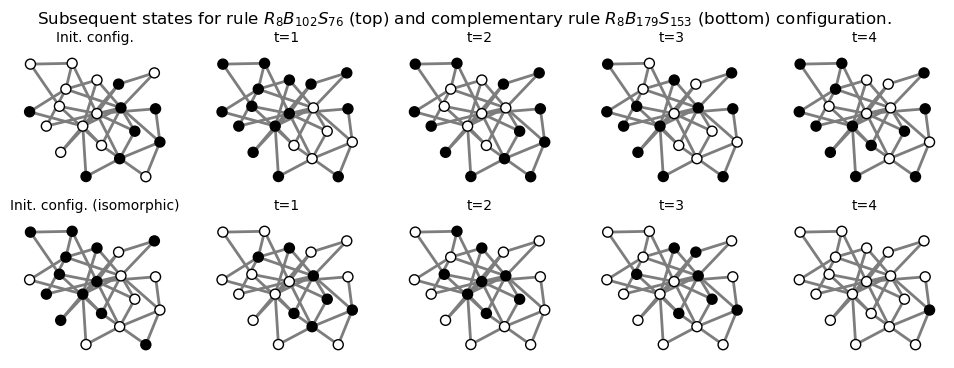

In [71]:
rule = model.__str__(latex=True)
rule_comp = model_iso.__str__(latex=True)

# random initial condition and its complement
s0 = np.random.randint(2, size=N).astype(float)
s0_iso = 1-s0

# open figure
fig, axs = plt.subplots(2,5,figsize=(12,4))
size=10

G.vs["states"] = s0
ig.plot(G, target=axs[0,0], **plot_params(G, labels=False))
axs[0,0].set_title("Init. config.", size=size)

# assign to state property of graph
# turn configuration into tc tensor and add extra dimension for number of samples
st = tc.tensor(s0)[None,:]
for t, ax in enumerate(axs[0,1:]):
    # evolve over one time step
    st = model.step(edges, st)
    G.vs["states"] = np.array(st[0])
    ig.plot(G, target=ax, **plot_params(G, labels=False))
    ax.set_title(f"t={t+1}", size=size)

# rinse and repeat for isomorphic NA
G.vs["states"] = s0_iso
ig.plot(G, target=axs[1,0], **plot_params(G, labels=False))
axs[1,0].set_title("Init. config. (isomorphic)", size=size)

st = tc.tensor(s0_iso)[None,:]
for t, ax in enumerate(axs[1,1:]):
    # evolve over one time step
    st = model_iso.step(edges, st)
    G.vs["states"] = np.array(st[0])
    ig.plot(G, target=ax, **plot_params(G, labels=False))
    ax.set_title(f"t={t+1}", size=size)

_=fig.suptitle(f"Subsequent states for rule {rule} (top) and complementary rule {rule_comp} (bottom) configuration.")